# Ch9 Playground — 基變換 Change of Basis

> 對應 3Blue1Brown《線性代數的本質》第九章
>
> 一個向量「實際上」是什麼方向、有多長，是物理事實。但**用一串數字表示它**這件事，要先選好一組「尺」 — 也就是基底（basis）。換尺子，數字就會變。
>
> 這集要回答兩個問題：
> 1. **同一個向量**在不同基底下，座標如何互換？
> 2. **同一個線性變換**在不同基底下，矩陣表示如何互換？

## 故事設定

你跟 Jennifer 看的是同一個 2D 空間。
- **你的基底** $\hat{i} = \binom{1}{0},\ \hat{j} = \binom{0}{1}$（標準 xy 座標）
- **Jennifer 的基底** $\vec{b}_1 = \binom{2}{1},\ \vec{b}_2 = \binom{-1}{1}$（在你眼裡這樣寫；她自己當然認為這兩個是 $\binom{1}{0}$ 和 $\binom{0}{1}$）

現在 Jennifer 指著一個向量說「在我看來它是 $\binom{-1}{2}$」。  
你看到的同一個向量座標是？又該怎麼把彼此的話翻譯回去？

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# Helper：在我們的座標下畫一組基底張成的網格
def draw_grid(ax, basis=None, color='#bbbbbb', n=7, lw=0.6):
    B = np.eye(2) if basis is None else np.asarray(basis, dtype=float)
    rng_ = np.arange(-n, n + 1)
    for k in rng_:
        # "vertical" lines in the basis frame
        p0 = B @ np.array([k, -n]); p1 = B @ np.array([k, n])
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, lw=lw)
        # "horizontal" lines
        p0 = B @ np.array([-n, k]); p1 = B @ np.array([n, k])
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], color=color, lw=lw)

def draw_vec(ax, v, color='black', label=None, origin=(0, 0), lw=2.2):
    ax.annotate('', xy=v, xytext=origin,
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))
    if label:
        ax.text(v[0] * 1.05, v[1] * 1.05, label, color=color, fontsize=11)

print('✔ Setup ready.')

✔ Setup ready.


---
## Part 1：同一個向量，不同座標

Jennifer 在她的世界裡寫下的座標 $\binom{-1}{2}$ 對她來說的意思是：

$$ -1 \cdot \vec{b}_1 + 2 \cdot \vec{b}_2 $$

**而 $\vec{b}_1, \vec{b}_2$ 在我們的座標下是已知的**，所以我們可以直接算出它在我們座標下是多少：

$$ -1 \cdot \binom{2}{1} + 2 \cdot \binom{-1}{1} = \binom{-4}{1} $$

**重點**：把 Jennifer 的座標 $\binom{-1}{2}$ 當成「線性組合的係數」，去組合 $\vec{b}_1, \vec{b}_2$，就得到我們眼裡的座標。

In [2]:
# === 實驗 1：手動把 Jennifer 的座標換成我們的座標 ===

b1 = np.array([2.0, 1.0])    # Jennifer 的 b1（用我們的座標寫）
b2 = np.array([-1.0, 1.0])   # Jennifer 的 b2

# Jennifer 說：「這向量在我看來是 (-1, 2)」
v_jennifer = np.array([-1.0, 2.0])

# 我們眼裡：v = -1·b1 + 2·b2
v_ours = v_jennifer[0] * b1 + v_jennifer[1] * b2
print('在我們座標下:', v_ours)

在我們座標下: [-4.  1.]


---
## Part 2：把這個過程打包成一個矩陣 — Change-of-Basis 矩陣 $A$

上面這個「拿係數去組 $\vec{b}_1, \vec{b}_2$」的操作，正好就是矩陣乘法的定義！

$$ A = \bigl[\,\vec{b}_1\ \big|\ \vec{b}_2\,\bigr] = \begin{bmatrix} 2 & -1 \\ 1 & 1 \end{bmatrix} $$

$$ \vec{v}_{\text{ours}} = A \, \vec{v}_{\text{Jennifer}} $$

$A$ 把每個 column 是「Jennifer 的基底向量在我們眼裡的座標」。  
**幾何意義**：$A$ 把標準網格「掰歪」成 Jennifer 的網格。

> 直覺口訣：**$A$ 把 Jennifer 的話翻譯成我的話**。

A =
 [[ 2. -1.]
 [ 1.  1.]]
A @ v_jennifer = [-4.  1.]
跟手算一致？ True


/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_49184/1565548213.py:30: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_49184/1565548213.py:30: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_49184/1565548213.py:30: UserWarning: Glyph 20491 (\N{CJK UNIFIED IDEOGRAPH-500B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_49184/1565548213.py:30: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_49184/1565548213.py:30: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu

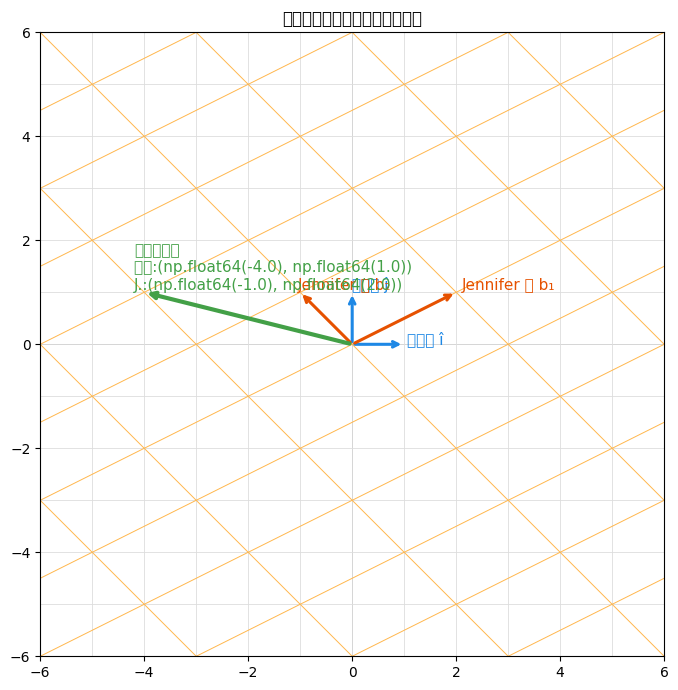

In [3]:
# === 實驗 2：用矩陣 A 完成翻譯，並視覺化兩套網格 ===

A = np.column_stack([b1, b2])
print('A =\n', A)

v_ours_via_A = A @ v_jennifer
print('A @ v_jennifer =', v_ours_via_A)
print('跟手算一致？', np.allclose(v_ours_via_A, v_ours))

# ── 視覺化 ──
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal'); ax.set_xlim(-6, 6); ax.set_ylim(-6, 6)
ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)

# 我們的標準網格（淺灰）
draw_grid(ax, basis=None, color='#dddddd')
# Jennifer 的網格（橘色）
draw_grid(ax, basis=A, color='#FFB74D', lw=0.7)

# 兩組基底向量
draw_vec(ax, [1, 0], color='#1E88E5', label='我們的 î')
draw_vec(ax, [0, 1], color='#1E88E5', label='我們的 ĵ')
draw_vec(ax, b1, color='#E65100', label='Jennifer 的 b₁')
draw_vec(ax, b2, color='#E65100', label='Jennifer 的 b₂')

# 同一個向量
draw_vec(ax, v_ours, color='#43A047', label=f'同一個向量\n我們:{tuple(v_ours)}\nJ.:{tuple(v_jennifer)}', lw=3)

ax.set_title('同一個向量在兩套座標下的表示')
plt.tight_layout(); plt.show()

---
## Part 3：反方向 — $A^{-1}$ 把我們的話翻譯成 Jennifer 的話

如果現在反過來：你指著 $\binom{3}{2}$（你的座標）跟 Jennifer 說「看那個」。她的座標表示是？

我們要解：「找哪些係數 $(c_1, c_2)$ 能讓 $c_1 \vec{b}_1 + c_2 \vec{b}_2 = \binom{3}{2}$」。  
也就是解 $A \, \vec{v}_{\text{Jennifer}} = \vec{v}_{\text{ours}}$，所以：

$$ \vec{v}_{\text{Jennifer}} = A^{-1} \, \vec{v}_{\text{ours}} $$

口訣：**$A$ 翻成我的話，$A^{-1}$ 翻成她的話**。

In [4]:
# === 實驗 3：A^(-1) 把我們的座標翻譯成 Jennifer 的座標 ===

A_inv = np.linalg.inv(A)
print('A^(-1) =\n', A_inv)

v_ours_2 = np.array([3.0, 2.0])
v_jennifer_2 = A_inv @ v_ours_2
print(f'\n我們眼裡 {tuple(v_ours_2)} → Jennifer 眼裡 {tuple(np.round(v_jennifer_2, 4))}')

# 驗證
print('反向回來：A @ v_jennifer_2 =', A @ v_jennifer_2)
print('一致？', np.allclose(A @ v_jennifer_2, v_ours_2))

A^(-1) =
 [[ 0.3333  0.3333]
 [-0.3333  0.6667]]

我們眼裡 (np.float64(3.0), np.float64(2.0)) → Jennifer 眼裡 (np.float64(1.6667), np.float64(0.3333))
反向回來：A @ v_jennifer_2 = [3. 2.]
一致？ True


---
## Part 4：線性變換在不同基底下長什麼樣？

現在問題升級。設 $M$ 是「**逆時針旋轉 90°**」這個變換。在**我們**的標準基底下：

$$ M = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} $$

Jennifer 看的是同一個物理動作（把向量轉 90°），但她用她的尺寫出來的矩陣 $M'$ 跟 $M$ 完全不一樣。怎麼算 $M'$？

**「翻譯三步走」**：

1. Jennifer 給我們一個向量 $\vec{v}_J$（她的座標）。先用 $A$ 翻譯成我們的話：$A \vec{v}_J$
2. 在我們的世界裡做變換：$M (A \vec{v}_J)$
3. 把結果翻譯回她的話：$A^{-1} M A \vec{v}_J$

因此：

$$ \boxed{M' = A^{-1} M A} $$

這個式子叫做**相似變換（similarity transform）**，後面 Ch10 講特徵值的時候會再次出現。

In [5]:
# === 實驗 4：A^(-1) M A — 同一個變換在 Jennifer 基底下的矩陣 ===

M = np.array([[0.0, -1.0],
              [1.0,  0.0]])    # 我們眼裡的「逆時針 90°」

M_jennifer = A_inv @ M @ A
print("在 Jennifer 的基底下，'逆時針 90°' 的矩陣:")
print(M_jennifer)

# 數值驗證：在 Jennifer 那邊先做變換，再翻譯回我們的話，跟在我們這邊先做變換結果一致
for v_J in [[1, 0], [0, 1], [3, 2], [-1, 2]]:
    v_J = np.array(v_J, dtype=float)
    way1 = A @ (M_jennifer @ v_J)   # Jennifer 那邊變換後翻譯給我們
    way2 = M @ (A @ v_J)            # 翻譯後在我們這邊變換
    print(f'  v_J = {v_J}    A·M_J·v_J = {way1}    M·A·v_J = {way2}    一致？{np.allclose(way1, way2)}')

在 Jennifer 的基底下，'逆時針 90°' 的矩陣:
[[ 0.3333 -0.6667]
 [ 1.6667 -0.3333]]
  v_J = [1. 0.]    A·M_J·v_J = [-1.  2.]    M·A·v_J = [-1.  2.]    一致？True
  v_J = [0. 1.]    A·M_J·v_J = [-1. -1.]    M·A·v_J = [-1. -1.]    一致？True
  v_J = [3. 2.]    A·M_J·v_J = [-5.  4.]    M·A·v_J = [-5.  4.]    一致？True
  v_J = [-1.  2.]    A·M_J·v_J = [-1. -4.]    M·A·v_J = [-1. -4.]    一致？True


---
## Part 5：視覺化 — 同一個 90° 旋轉，看起來在 Jennifer 眼裡多奇怪

把 $M' = A^{-1} M A$ 的數字攤在你眼前看，會發現它**完全不是你心目中那個漂亮的「旋轉矩陣」** — 它有負數、有奇怪的非整數。但**它確實在 Jennifer 的世界做著一模一樣的物理動作**。

下面把 Jennifer 的網格、變換前後的向量都畫出來，看會更直覺。

/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_46080/2876382068.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_46080/2876382068.py:31: UserWarning: Glyph 25105 (\N{CJK UNIFIED IDEOGRAPH-6211}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_46080/2876382068.py:31: UserWarning: Glyph 20497 (\N{CJK UNIFIED IDEOGRAPH-5011}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_46080/2876382068.py:31: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/var/folders/w8/8vzd55_x56b1sds42r697h840000gn/T/ipykernel_46080/2876382068.py:31

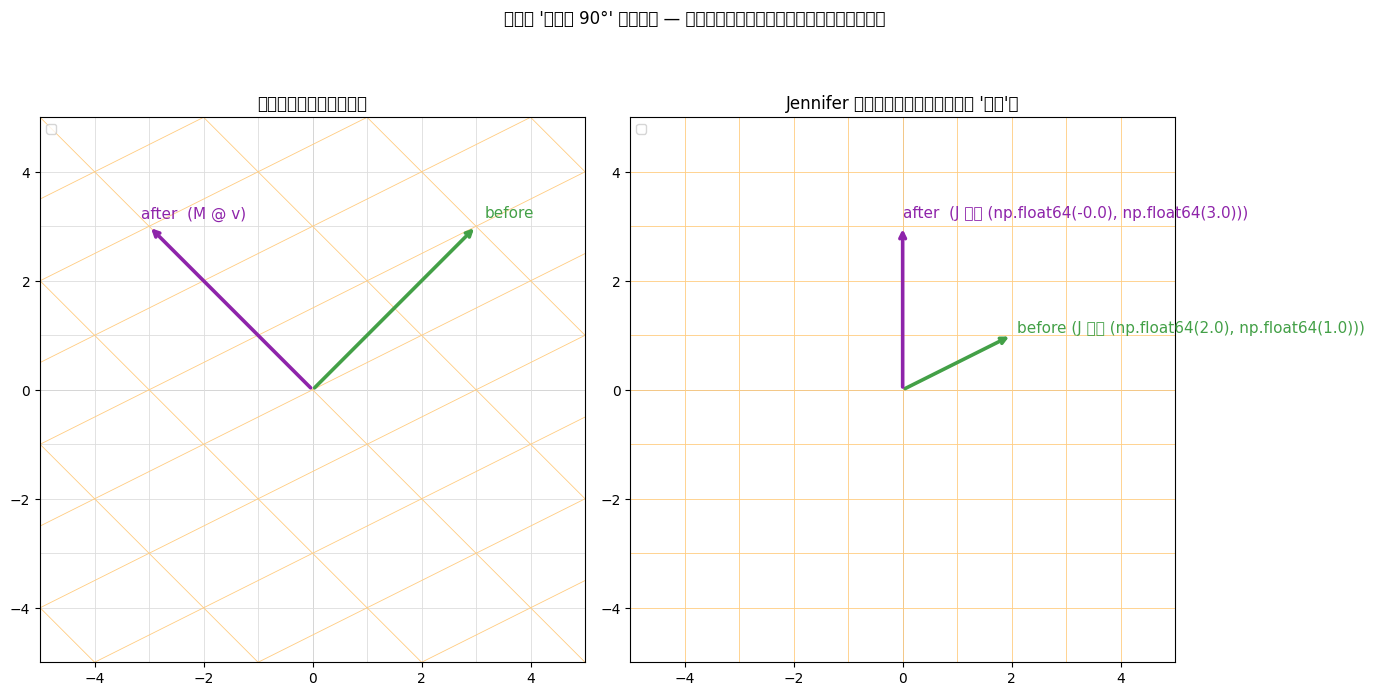

我們：[3. 3.] → [-3.  3.]
J. ：[2. 1.] → [-0.  3.]
A @ v_J_rotated 應該等於 v_ours_after：True


In [6]:
# === 實驗 5：視覺化 — 旋轉前後 ===

v_J = np.array([2.0, 1.0])             # Jennifer 看到的某向量
v_J_rotated = M_jennifer @ v_J         # 在 Jennifer 視角下旋轉後

v_ours_before = A @ v_J                # 同一個向量在我們眼裡
v_ours_after  = M @ v_ours_before      # 我們直接用 M 做旋轉

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, title in zip(axes, ['我們的視角（標準基底）', "Jennifer 的視角（她的網格被她當成 '正常'）"]):
    ax.set_aspect('equal'); ax.set_xlim(-5, 5); ax.set_ylim(-5, 5)
    ax.axhline(0, color='grey', lw=0.4); ax.axvline(0, color='grey', lw=0.4)
    ax.set_title(title)

# 左邊：我們眼裡，畫我們的網格 + Jennifer 的網格
draw_grid(axes[0], basis=None, color='#dddddd')
draw_grid(axes[0], basis=A, color='#FFCC80', lw=0.6)
draw_vec(axes[0], v_ours_before, color='#43A047', label='before', lw=2.6)
draw_vec(axes[0], v_ours_after,  color='#8E24AA', label='after  (M @ v)', lw=2.6)

# 右邊：Jennifer 自己的視角，她覺得 b1, b2 就是 (1,0), (0,1)。
# 為了模擬她的視角，我們直接畫「在她眼裡的座標」對應的標準網格。
draw_grid(axes[1], basis=None, color='#FFCC80')   # 她覺得自己的網格是正方形
draw_vec(axes[1], v_J,         color='#43A047', label=f'before (J 看到 {tuple(v_J)})', lw=2.6)
draw_vec(axes[1], v_J_rotated, color='#8E24AA', label=f'after  (J 看到 {tuple(np.round(v_J_rotated,2))})', lw=2.6)

for ax in axes:
    ax.legend(loc='upper left', fontsize=9)

plt.suptitle("同一個 '逆時針 90°' 物理動作 — 兩個視角看起來完全不同，但本質上同一件事", y=1.02)
plt.tight_layout(); plt.show()

print(f'我們：{np.round(v_ours_before, 2)} → {np.round(v_ours_after, 2)}')
print(f'J. ：{np.round(v_J, 2)} → {np.round(v_J_rotated, 2)}')
print(f'A @ v_J_rotated 應該等於 v_ours_after：{np.allclose(A @ v_J_rotated, v_ours_after)}')

In [7]:
# === 練習區：自由換 Jennifer 的基底，看 A^(-1) M A 怎麼變 ===

my_b1 = [3, 0]      # ← 改這裡（Jennifer 的 b1，用我們的座標寫）
my_b2 = [1, 2]      # ← 改這裡

A_p = np.column_stack([np.array(my_b1, float), np.array(my_b2, float)])
print('det(A) =', np.linalg.det(A_p), '(若為 0，b1, b2 共線，無法當基底！)')

if not np.isclose(np.linalg.det(A_p), 0):
    M_p = np.linalg.inv(A_p) @ M @ A_p
    print('在你選的基底下，「逆時針 90°」變成:\n', np.round(M_p, 4))
    print('\n直覺檢查：在 Jennifer 自己看，這個矩陣的 det 仍然 =', np.round(np.linalg.det(M_p), 4),
          '\n(因為旋轉不改變面積，跟基底無關！這是「不變量」的一個例子。)')

det(A) = 6.0 (若為 0，b1, b2 共線，無法當基底！)
在你選的基底下，「逆時針 90°」變成:
 [[-0.5    -0.8333]
 [ 1.5     0.5   ]]

直覺檢查：在 Jennifer 自己看，這個矩陣的 det 仍然 = 1.0 
(因為旋轉不改變面積，跟基底無關！這是「不變量」的一個例子。)


---
## 總結

| 場景 | 公式 | 直覺 |
|---|---|---|
| 向量：Jennifer → 我們 | $\vec{v}_{\text{ours}} = A \, \vec{v}_J$ | $A$ 把她的話翻成我的話 |
| 向量：我們 → Jennifer | $\vec{v}_J = A^{-1} \, \vec{v}_{\text{ours}}$ | $A^{-1}$ 翻回去 |
| 變換：我們的 $M$ → 她的 $M'$ | $M' = A^{-1} M A$ | 翻來→做事→翻回去 |
| 不變量 | $\det(M') = \det(M)$，trace 也不變 | 物理動作的本質跟描述用的尺無關 |

### 一句話記住

> 矩陣只是「**用某組基底寫下來的**線性變換」。換基底就像換語言：句子（變換）的意思沒變，只是寫法 $A^{-1} M A$ 看起來不同。

### 為什麼在深度學習裡這個觀點重要？

1. **PCA / SVD**：找到一組「特殊的基底」（特徵向量），讓資料矩陣的描述變得對角化、最簡潔。整個流程就是「用 $A^{-1} M A$ 把 $M$ 變漂亮」。
2. **Embedding 空間**：詞向量、圖片特徵都活在某個高維空間，但「基底是什麼」往往沒有 canonical 答案。理解「同一個資料 = 不同基底下的不同座標」對解釋 representation learning 很關鍵。
3. **預備 Ch10**：特徵向量就是「**讓 $A^{-1} M A$ 變成對角矩陣**的那組基底」 — 這是下一章的主題。